In [11]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Standardregler

## Versuch 5, Praktikum *Technische Grundlagen der künstlichen Intelligenz*

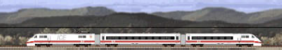

In diesem Versuch geht es um den Einsatz von Standardreglern am Beispiel eines simulierten Schubverbundes.  
Bei einem Schubverbund handelt es sich um eine Lokomotive, die (in unserem Beispiel zwei) Wagen vor sich her schiebt.  
Die Einheiten sind über Federn und Dämpfer miteinander gekoppelt und unterliegen einer geschwindigkeitsabhängigen Schienenreibung.  
Die Geschwindigkeit $v(t)$ des vorderen Wagens soll über die Schubkraft der Lokomotive $f(t)$ geregelt werden.

---

## 1. Simulation des Schubverbundes

Das System kann als der unten dargestellte Drei-Massen-Schwinger modelliert werden:

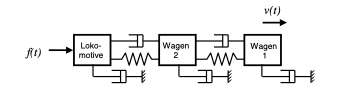

Die Stellgröße des Systems ist die Antriebskraft der Lokomotive in Vorwärtsrichtung

$$
u(t) = f(t) \qquad \text{in kN},
$$

die zu regelnde Ausgangsgröße des Systems ist die Geschwindigkeit des vorderen Wagens

$$
y(t) = v(t) \qquad \text{in m/s}.
$$

Die drei Elemente des Schubverbundes (Lok und zwei Wagen gleicher Masse $m$) werden nach dem zweiten Newtonschen Gesetz durch folgende Differentialgleichungen beschrieben:

### Lokomotive
$$
m_{\text{Lok}} \ddot{x}_{\text{Lok}}
= -R \dot{x}_{\text{Lok}}
- D(\dot{x}_{\text{Lok}} - \dot{x}_1)
- k(x_{\text{Lok}} - x_1 + \Delta x)
+ 1000 \cdot f(t)
$$

### Mittlerer Wagen
$$
m \ddot{x}_1
= -R \dot{x}_1
+ D(\dot{x}_{\text{Lok}} - \dot{x}_1)
+ k(x_{\text{Lok}} - x_1 + \Delta x)
- D(\dot{x}_1 - v)
- k(x_1 - x_2 + \Delta x)
$$

### Vorderer Wagen
$$
m \dot{v}
= m \ddot{x}_2
= -R v
+ D(\dot{x}_1 - v)
+ k(x_1 - x_2 + \Delta x)
$$

Dabei gelten folgende physikalische Konstanten:

- Reibungskoeffizient der Schienen und Räder:  
  $R = 200\ \text{Ns/m}$

- Dämpfungsbeiwerte der Kupplungen zwischen den Massen:  
  $D = 500\ \text{Ns/m}$

- Federkonstanten der Kupplungen:  
  $k = 200\ \text{N/m}$

- Masse der Lokomotive:  
  $m_{\text{Lok}} = 80\,000\ \text{kg}$

- Masse der Wagen:  
  $m = 15\,000\ \text{kg}$


In [21]:
# Globale Konstanten
R = 200         # Ns/m
D = 500         # Ns/m
k = 200         # N/m
m_lok = 80000   # kg
m = 15000       # Kg

In [22]:
# Modell des Schubverbundes (Differentialgleichungen)
def schubverbund_ode(t, X, f_func):
    # Unpack state vector
    x_lok, v_lok, x1, v1, x2, v2 = X
    # Input force at time t
    f = f_func(t)
    # Delta x cancels in the equations as per your description

    # Lokomotive
    dv_lok = ( -R*v_lok - D*(v_lok - v1) - k*(x_lok - x1) + 1000*f ) / m_lok
    # Mittlerer Wagen
    dv1 = ( -R*v1 + D*(v_lok - v1) + k*(x_lok - x1)
            - D*(v1 - v2) - k*(x1 - x2) ) / m
    # Vorderer Wagen
    dv2 = ( -R*v2 + D*(v1 - v2) + k*(x1 - x2) ) / m

    return [v_lok, dv_lok, v1, dv1, v2, dv2]

In [23]:
# Einheitsprung 1 kN als Stellgröße durch die Lok
def step_input(t):
    return 1.0  # constant force of 1 kN

In [24]:
# Anfangszustand (alle Positionen und Geschwindigkeiten sind Null)
X0 = [0, 0, 0, 0, 0, 0]

# Zeitspanne
t_span = (0, 1000) # von 0 bis 1000 s
t_eval = np.linspace(*t_span, 1000) # mit 1000 Zwischenwerten

# Simulation (Integration der Differentialgleichungen)
sol = solve_ivp(schubverbund_ode, t_span, X0, args=(step_input,), t_eval=t_eval)

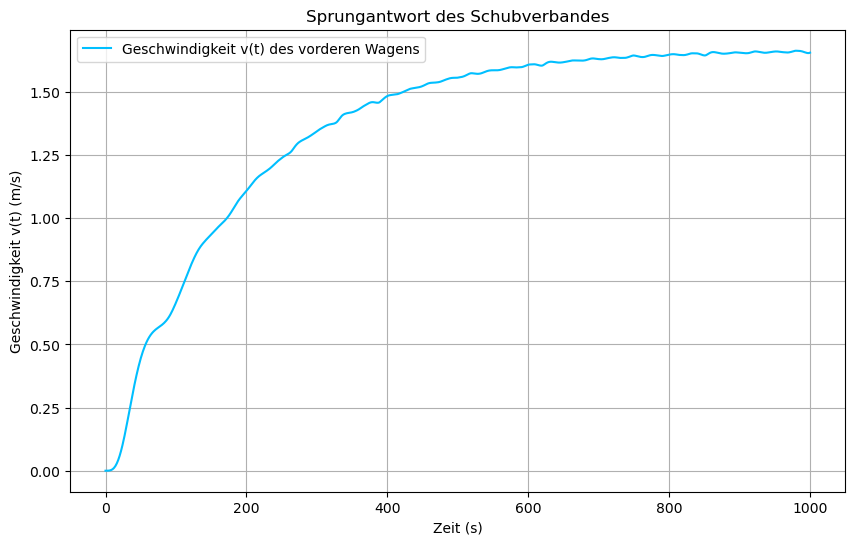

In [25]:
# Geschwindigkeit des vorderen Wagens ist Variable No. 5
v_front = sol.y[5]

# Plot
plt.figure(figsize=(10,6))
plt.plot(sol.t, v_front, label='Geschwindigkeit v(t) des vorderen Wagens', color='deepskyblue')
plt.xlabel('Zeit (s)')
plt.ylabel('Geschwindigkeit v(t) (m/s)')
plt.title('Sprungantwort des Schubverbandes')
plt.grid(True)
plt.legend()

### 2. Proportionalregler

Wir implementieren den P-Regler als Python-Objekt, wobei wir von einer Festwertregelung ausgehen (Der Sollwert ist der Funktionsparameter soll):

In [26]:
class PController:
    def __init__(self, Kp, soll=0.0):
        self.Kp = Kp
        self.soll = soll

    def __call__(self, regelgr, zeitpunkt):
        error = self.soll - regelgr

        # Proportionalterm
        output = self.Kp * error
        return output

Der P-Regler wird nun vor das Modell des Schubverbandes geschaltet und die Geschwindigkeit des vorderen Wagens wird als Regelgröße rückgegführt, so dass der Regelkreis geschlossen ist. Das Reglerobjekt wird als Argument ctrl an die Funktion übergeben:

In [ ]:
def schubverbund_mit_regler(zeitpunkt, X, ctrl):
    # Regelgröße: Geschwindigkeit des vorderen Wagons
    v_front = X[5]

    # Berechne die Stellkraft mithilfe des Reglers
    f = ctrl(v_front, zeitpunkt)
    
    #

    # Selbes Modell wie vorhin, aber mit Stellkraft des Reglers als Input
    x_lok, v_lok, x1, v1, x2, v2 = X

    dv_lok = (-R*v_lok - D*(v_lok - v1) - k*(x_lok - x1) + 1000*f) / m_lok # Lok
    dv1 = (-R*v1 + D*(v_lok - v1) + k*(x_lok - x1) - D*(v1 - v2) - k*(x1 - x2)) / m # Mittlerer Wagen
    dv2 = (-R*v2 + D*(v1 - v2) + k*(x1 - x2)) / m # Vorderer Wagen

    return [v_lok, dv_lok, v1, dv1, v2, dv2]

Für die Simulation wird das Reglerobjekt angelegt, ansonsten läuft alles wie vorher. Wie erhalten so die Sprungantwort des geregelten Schubverbandes.

In [28]:
# P-Regler Werte 0.5,1,2,4, 
ctrl = PController(Kp=0.5, soll=1.0)  # Sollwert 1 ergibt die Sprungantwort

# Anfangsbedingungen und Zeitspanne wie vorhin
X0 = [0, 0, 0, 0, 0, 0]
t_span = (0, 1000)
t_eval = np.linspace(*t_span, 1000)


# Simulation 
sol = solve_ivp(schubverbund_mit_regler, t_span, X0, args=(ctrl,), t_eval=t_eval)

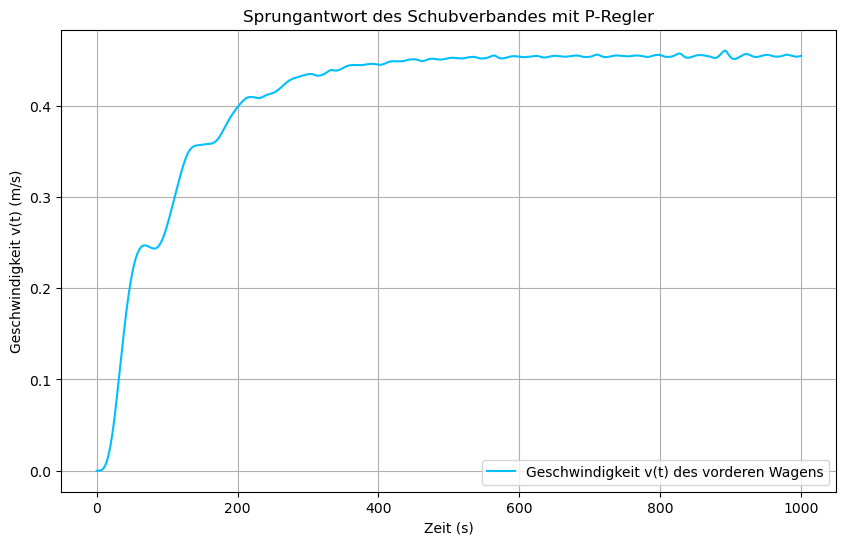

In [29]:
# Geschwindigkeit des vorderen Wagens ist Variable No. 5
v_front = sol.y[5]

# Plot
plt.figure(figsize=(10,6))
plt.plot(sol.t, v_front, label='Geschwindigkeit v(t) des vorderen Wagens', color='deepskyblue')
plt.xlabel('Zeit (s)')
plt.ylabel('Geschwindigkeit v(t) (m/s)')
plt.title('Sprungantwort des Schubverbandes mit P-Regler')
plt.grid(True)
plt.legend()

**Aufgaben:**
- Steigern Sie die Reglerverstärkung in mehreren Schritten. Wie verändert sich dabei der
Geschwindigkeitsverlauf?
- Wie verhält sich die Regeldifferenz?
- Ab welcher Verstärkung wird das System instabil?
- Implementieren Sie eine Stellgrößenbeschränkung und vergleichen Sie das Ergebnis.

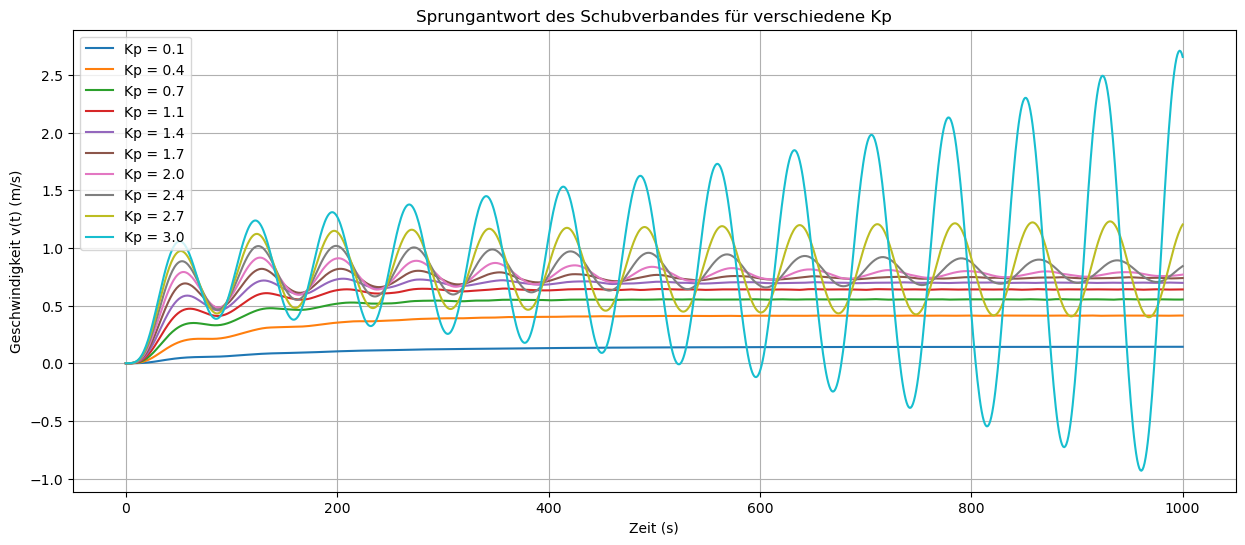

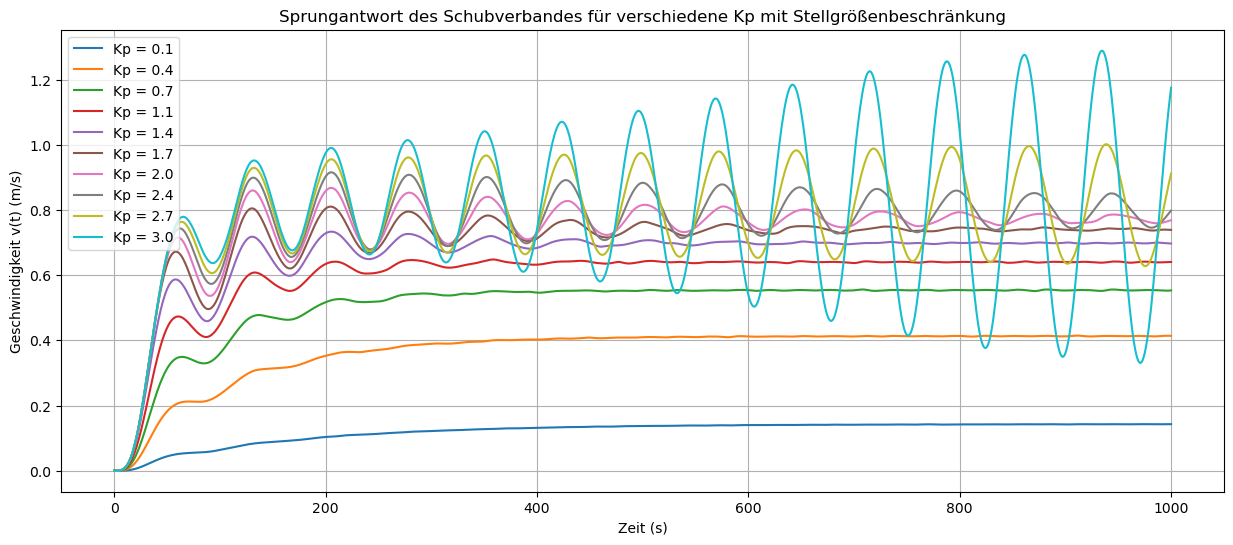

'\nDie Schwingungen welche stark schwingten wurden jetzt gebremst. Was wir hier gemacht haben ist im endeffekt\neine Physikalische grenze. Mathematisch gesehen könnte eine schwingung bis ins unendliche gehen, das funktioniert aber in der\nrelität nicht. Es gibt harte grenzen beim Motor, Strom oder Widerstände. Genau das ist die Stellengrößenbeschränkung. Diese\nsorgt dafür, dass unsere Simulation etwas genauer bzw realitätstreuer wirkt.\n\nOder noch besser es ist wie eine schaukel:\nIn einem idealen Modell könnte man die Schaukel immer stärker anschubsen, wenn unbegrenzt Kraft zur Verfügung steht.\nIn der Realität ist die Kraft, mit der man anschubsen kann, jedoch begrenzt.\nDadurch ist auch die zugeführte Energie begrenzt, während Reibung und Luftwiderstand weiterhin Energie abbauen.\nFolglich klingen die Schwingungen ab.\n\nDie Stellgrößenbeschränkung entspricht dieser Kraftbegrenzung und verhindert, dass der Regler dem System unbegrenzt Energie zuführt.\n\n'

In [83]:
'''
Was genau macht kp eigentlich?
Ein P-Regler erzeugt eine Stellgröße proportional zur momentanen Abweichung zwischen
Sollwert und Istwert. Die Reglerrverstärkung Kp bestimmt, wie stark auf diesen Fehler
reagiert wird. In der Analogie eines Lokführeres entspricht Kp der Stärke, mit der der
Lokführer bei einer Abweichung vom Solltempo Gas gibt.
'''

# Ihre Lösung hier
import numpy as np

Kp_values = np.linspace(0.1, 3, 10)
sollwert = 1.0

plt.figure(figsize=(15,6))
for kp in Kp_values:
    ctrl = PController(Kp=kp, soll=sollwert)
    sol = solve_ivp(schubverbund_mit_regler, t_span, X0, args=(ctrl,), t_eval=t_eval)

    # Geschwindigkeit des vorderen Wagens ist Variable No. 5
    v_front = sol.y[5]
    
    plt.plot(sol.t, v_front, label=f"Kp = {kp:.1f}")

# Plot
plt.xlabel('Zeit (s)')
plt.ylabel('Geschwindigkeit v(t) (m/s)')
plt.title('Sprungantwort des Schubverbandes für verschiedene Kp')
plt.grid(True)
plt.legend()
plt.show()


def schubverbund_mit_regler2(zeitpunkt, X, ctrl, beschraenkung=5):
    # Regelgröße: Geschwindigkeit des vorderen Wagons
    v_front = X[5]

    # Berechne die Stellkraft mithilfe des Reglers
    f = ctrl(v_front, zeitpunkt)
    
    # hier kommt die stellgrößenbeschränkung
    f = np.clip(f, -beschraenkung, beschraenkung)

    # Selbes Modell wie vorhin, aber mit Stellkraft des Reglers als Input
    x_lok, v_lok, x1, v1, x2, v2 = X

    dv_lok = (-R*v_lok - D*(v_lok - v1) - k*(x_lok - x1) + 1000*f) / m_lok # Lok
    dv1 = (-R*v1 + D*(v_lok - v1) + k*(x_lok - x1) - D*(v1 - v2) - k*(x1 - x2)) / m # Mittlerer Wagen
    dv2 = (-R*v2 + D*(v1 - v2) + k*(x1 - x2)) / m # Vorderer Wagen

    return [v_lok, dv_lok, v1, dv1, v2, dv2]


plt.figure(figsize=(15,6))
for kp in Kp_values:
    ctrl = PController(Kp=kp, soll=sollwert)
    sol = solve_ivp(schubverbund_mit_regler2, t_span, X0, args=(ctrl, 1.5), t_eval=t_eval)

    # Geschwindigkeit des vorderen Wagens ist Variable No. 5
    v_front = sol.y[5]
    
    plt.plot(sol.t, v_front, label=f"Kp = {kp:.1f}")

# Plot
plt.xlabel('Zeit (s)')
plt.ylabel('Geschwindigkeit v(t) (m/s)')
plt.title('Sprungantwort des Schubverbandes für verschiedene Kp mit Stellgrößenbeschränkung')
plt.grid(True)
plt.legend()
plt.show()

'''
Die Schwingungen welche stark schwingten wurden jetzt gebremst. Was wir hier gemacht haben ist im endeffekt
eine Physikalische grenze. Mathematisch gesehen könnte eine schwingung bis ins unendliche gehen, das funktioniert aber in der
relität nicht. Es gibt harte grenzen beim Motor, Strom oder Widerstände. Genau das ist die Stellengrößenbeschränkung. Diese
sorgt dafür, dass unsere Simulation etwas genauer bzw realitätstreuer wirkt.

Oder noch besser es ist wie eine schaukel:
In einem idealen Modell könnte man die Schaukel immer stärker anschubsen, wenn unbegrenzt Kraft zur Verfügung steht.
In der Realität ist die Kraft, mit der man anschubsen kann, jedoch begrenzt.
Dadurch ist auch die zugeführte Energie begrenzt, während Reibung und Luftwiderstand weiterhin Energie abbauen.
Folglich klingen die Schwingungen ab.

Die Stellgrößenbeschränkung entspricht dieser Kraftbegrenzung und verhindert, dass der Regler dem System unbegrenzt Energie zuführt.

'''


## 3. PI-Regler

Erweitern Sie nun den P-Regler zu einem PI-Regler, indem Sie das Proportionalglied um ein Integralglied erweitern. Als weiterer Parameter kommt jetzt die Nachstellzeit $T_N$ hinzu. Verwenden Sie dazu den Positionsalgorithmus. **Achtung:** Der Abstand der Zeitpunkte $\Delta t$ ist bei dieser Simulation nicht konstant! Sie müssen daher den vergangenen Zeitpunkt in einer Variable im Reglerobjekt speichern und die Differenz zum momentanen Zeitpunkt bei jeder Iteration neu berechnen. Speichern Sie auch den vergangenen Wert des Integrals in einer Variable, so dass Sie das Integral $\frac{1}{T_N} \sum_{j=0}^{k-1} e_j \Delta t$ inkrementell bei jedem Zeitschritt berechnen können.

In [86]:
# Hier Ihr PI-Regler als Python-Objekt
'''
Man kann sich den PI-Regler wie einen Tempomaten im Auto vorstellen.
Er merkt sich die Abweichung vom Sollwert über die Zeit, gleicht Verluste wie Luft- und Rollwiderstand aus und kann dadurch eine konstante Geschwindigkeit halten.

Ein reiner P-Regler reagiert hingegen nur auf den momentanen Fehler. Ist das Fahrzeug etwas zu langsam, gibt er Gas; ist es etwas zu schnell, nimmt er Gas weg.
Je nach Reglerverstärkung kann es dabei zu Überschwingen und Schwingungen kommen, und aufgrund der Verluste bleibt oft ein stationärer Fehler bestehen.
'''


'\nMan kann sich den PI-Regler wie einen Tempomaten im Auto vorstellen.\nEr merkt sich die Abweichung vom Sollwert über die Zeit, gleicht Verluste wie Luft- und Rollwiderstand aus und kann dadurch eine konstante Geschwindigkeit halten.\n\nEin reiner P-Regler reagiert hingegen nur auf den momentanen Fehler. Ist das Fahrzeug etwas zu langsam, gibt er Gas; ist es etwas zu schnell, nimmt er Gas weg.\nJe nach Reglerverstärkung kann es dabei zu Überschwingen und Schwingungen kommen, und aufgrund der Verluste bleibt oft ein stationärer Fehler bestehen.\n'

**Aufgaben:**
- Testen Sie Ihren PI Regler in der obigen Simulation, zunächst mit $K_p = 1$ und $T_N = 10$. Welcher gravierende Unterschied besteht zum P-Regler?
- Verändern Sie schrittweise die Nachstellzeit. Wie verändert sich das Regelverhalten?
- Was passiert, wenn man zusätzlich die Verstärkung verändert (z.B. Ki = 0.1, 0.01, . . .)?
- Entwerfen Sie mit den bisher gemachten Erfahrungen einen PI-Regler, der ein möglichst gutes Regelverhalten hat, also eine möglichst kurze Einschwingzeit und möglichst geringes Überschwingen.

In [87]:
# Ihre Lösung hier

class PIController:
    def __init__(self, Kp, Tn, soll=0.0):
        self.Kp = Kp
        self.Tn = Tn
        self.soll = soll

        # interner Zustand
        self.integral = 0.0
        self.t_last = None

    def __call__(self, regelgr, t):
        # Fehler
        e = self.soll - regelgr

        # erstes Aufrufen → kein Δt
        if self.t_last is None:
            dt = 0.0
        else:
            dt = t - self.t_last

        # Integral inkrementell aktualisieren
        if dt > 0.0:
            self.integral += (e * dt) / self.Tn

        # Zeit merken
        self.t_last = t

        # PI-Positionsalgorithmus
        u = self.Kp * (e + self.integral)
        return u


## 4. D- und PD-Regler

Implementieren Sie nun einen reinen D-Regler mithilfe des Rückwärtsgradienten. Speichern Sie dazu ähnlich wie beim PI-Regler die vergangene Regelabweichung in Ihrem Reglerobjekt. 

In [ ]:
# Hier Ihr D-Regler als Python-Objekt
class DController:
    def __init__(self, Kd, soll=0.0):
        self.Kd = Kd
        self.soll = soll

        # gespeicherter Zustand
        self.e_last = None
        self.t_last = None

    def __call__(self, regelgr, t):
        # aktuelle Regelabweichung
        e = self.soll - regelgr

        # erstes Aufrufen → keine Ableitung möglich
        if self.t_last is None:
            de_dt = 0.0
        else:
            dt = t - self.t_last
            if dt > 0.0:
                de_dt = (e - self.e_last) / dt
            else:
                de_dt = 0.0

        # Zustand speichern
        self.e_last = e
        self.t_last = t

        # reiner D-Regler
        u = self.Kd * de_dt
        return u




Testen Sie nun Ihren D-Regler in der Simulation. Warum funktioniert der Regler nicht?

In [ ]:
# Ihre Lösung hier

# Es fehlen hier noch einige Parameter

ctrl = DController(Kd=0.5, soll=1.0)

sol = solve_ivp(
    schubverbund_mit_regler,
    t_span,
    X0,
    args=(ctrl,),
    t_eval=t_eval
)

Implementieren Sie nun einen PD-Regler. Wählen Sie zunächst $K_p = 1$ und $T_v = 0.1$.

In [ ]:
# Hier Ihr PD-Regler als Python-Objekt
class PDController:
    def __init__(self, Kp=1.0, Tv=0.1, soll=0.0):
        self.Kp = Kp
        self.Tv = Tv
        self.soll = soll

        # gespeicherter Zustand
        self.e_last = None
        self.t_last = None

    def __call__(self, regelgr, t):
        # aktuelle Regelabweichung
        e = self.soll - regelgr

        # D-Anteil (Rückwärtsgradient)
        if self.t_last is None:
            de_dt = 0.0
        else:
            dt = t - self.t_last
            if dt > 0.0:
                de_dt = (e - self.e_last) / dt
            else:
                de_dt = 0.0

        # Zustand speichern
        self.e_last = e
        self.t_last = t

        # PD-Positionsalgorithmus
        u = self.Kp * (e + self.Tv * de_dt)
        return u


Wie verhält sich der PD-Regler im Vergleich zu den vorigen Reglern? Kann man zu einem
zufriedenstellenden Ergebnis gelangen, indem man die Parameter verstellt?

In [ ]:
# Ihre Lösung hier

# Hier kommen noch die anderen simulationen hin und die Plots um diese zu vergleichen

ctrl = PDController(Kp=1.0, Tv=0.1, soll=1.0)

sol = solve_ivp(
    schubverbund_mit_regler,
    t_span,
    X0,
    args=(ctrl,),
    t_eval=t_eval
)


## 5. PID-Regler

Entwerfen Sie nun mit den gemachten Erfahrungen einen PID-Regler, der die Regelungsaufgabe möglichst gut erfüllt.

In [ ]:
# Ihre Lösung hier

class PIDController:
    def __init__(self, Kp, Tn, Tv, soll=0.0):
        self.Kp = Kp
        self.Tn = Tn
        self.Tv = Tv
        self.soll = soll

        # interner Zustand
        self.integral = 0.0
        self.e_last = None
        self.t_last = None

    def __call__(self, regelgr, t):
        # Regelabweichung
        e = self.soll - regelgr

        # Zeitschritt
        if self.t_last is None:
            dt = 0.0
            de_dt = 0.0
        else:
            dt = t - self.t_last
            if dt > 0.0:
                de_dt = (e - self.e_last) / dt
            else:
                de_dt = 0.0

        # Integralanteil (inkrementell)
        if dt > 0.0:
            self.integral += (e * dt) / self.Tn

        # Zustand speichern
        self.e_last = e
        self.t_last = t

        # PID-Positionsalgorithmus
        u = self.Kp * (e + self.integral + self.Tv * de_dt)
        return u
    
    
# verwendung

ctrl = PIDController(
    Kp=1.0,
    Tn=5.0,
    Tv=0.1,
    soll=1.0
)

sol = solve_ivp(
    schubverbund_mit_regler,
    t_span,
    X0,
    args=(ctrl,),
    t_eval=t_eval
)

